# Project 3 — Pandas frequency tables of token lengths

**Chapter 2 · Tokenization** · pp. 31–34

Measure how long GPT-2 tokens are (in characters) and study the distribution of those lengths — first for one paragraph, then across the 10 Project Gutenberg books — using pandas frequency tables and seaborn.

In [28]:
import requests

import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [29]:
### matplotlib adjustments
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top":   False,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "savefig.dpi": 300,
})

# **Part 1: Lengths of Stravinsky tokens**

In [30]:
# GPT2 tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")

In [31]:
# https://en.wikipedia.org/wiki/Pulcinella_(ballet)
txt = "Pulcinella is a 21-section ballet by Igor Stravinsky with arias for soprano, tenor and bass vocal soloists, and two sung trios. It is based on the 18th-century play Quatre Polichinelles semblables, or Four similar Pulcinellas, revolving around a stock character from commedia dell'arte. The work premiered at the Paris Opera on 15 May 1920 under the baton of Ernest Ansermet. The central dancer, Léonide Massine, created both the libretto and the choreography, while Pablo Picasso designed the costumes and sets. The ballet was commissioned by Sergei Diaghilev, impresario of the Ballets Russes. A complete performance takes 35–40 minutes. Stravinsky revised the score in 1965."

tokens = tokenizer.encode(txt)
unique_tokens = set(tokens)
print(f"There are {len(txt.split())} words and {len(tokens)} tokens ({len(unique_tokens)} of which are unique).")



There are 104 words and 174 tokens (129 of which are unique).


In [32]:
# qualitative confirmation
decoded_tokens = tokenizer.decode(tokens)
print(decoded_tokens)

# quantitative confirmation
print(f"\nAre they the same? --> {decoded_tokens == txt}")

Pulcinella is a 21-section ballet by Igor Stravinsky with arias for soprano, tenor and bass vocal soloists, and two sung trios. It is based on the 18th-century play Quatre Polichinelles semblables, or Four similar Pulcinellas, revolving around a stock character from commedia dell'arte. The work premiered at the Paris Opera on 15 May 1920 under the baton of Ernest Ansermet. The central dancer, Léonide Massine, created both the libretto and the choreography, while Pablo Picasso designed the costumes and sets. The ballet was commissioned by Sergei Diaghilev, impresario of the Ballets Russes. A complete performance takes 35–40 minutes. Stravinsky revised the score in 1965.

Are they the same? --> True


In [36]:
# loop through tokens and print out their lengths
token_lens = [len(tokenizer.decode(t)) for t in tokens]
print(token_lens[9])
print(tokenizer.decode(tokens[9]))

7
section


In [34]:
# create a pandas dataframe
df = pd.DataFrame({"token": tokens, "length": token_lens})
df.head()

,token,length
0,47,1
1,377,2
2,66,1
3,500,3
4,8466,3


In [39]:
# frequency table: for each distinct token length, how many tokens have that length.
# returns a Series (index = the length, values = the count), sorted most-common first.
val_counts = df["length"].value_counts()
val_counts


length
4     38
3     36
1     25
2     23
5     19
6     11
7      9
8      5
10     3
9      3
13     1
12     1
Name: count, dtype: int64

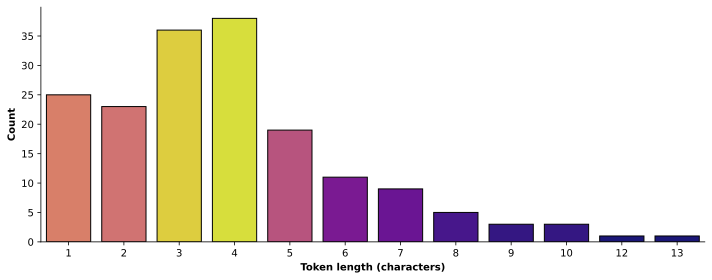

In [40]:
# specify figure size
plt.figure(figsize=(10, 4))

# draw the bar plot
sns.barplot(
    x=val_counts.index, 
    y=val_counts.values, 
    edgecolor="k", 
    hue=val_counts.values,
    palette="plasma",
    legend=False)

# adjustments
plt.gca().set(
    xlabel="Token length (characters)",
    ylabel="Count"
)

plt.tight_layout()
plt.savefig("images/ch2-proj3-pt1.png")
plt.show()


**How to read this chart:** each bar is a token *length* (in characters), and its height is **how many of the paragraph's 174 tokens have that length**. So the length-4 bar at 38 means 38 of the tokens are 4 characters long; the length-1 bar at 25 means 25 tokens are a single character. The bar heights add up to 174 — the total token count. It says nothing about *which* tokens or whether any repeat; only how token lengths are distributed.

**Example — the 38 length-4 tokens are 26 *different* tokens, not one repeated.** Two of them from this very paragraph:

- token id `262` -> `" the"`  (space + "the" = 4 characters)
- token id `290` -> `" and"`  (space + "and" = 4 characters)

Both land in the same length-4 bar because they share a *length*, even though they are completely different tokens. (GPT-2 folds the leading space into the token, which is why ` the` counts as 4, not 3.)